#Data Loading & Initial exploration

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("dataset_61.csv")

In [3]:
df.head(10)

,Review_ID,Product_ID,User_ID,Review_Date,Rating,Review_Text,Verified_Purchase,Extra_1
0,R525143,P5201,U44005,2024-12-06,4.0,Behavior them culture carry ready single clear...,No,dog
1,R518303,P2080,U64343,2025-07-14,NaN,Only suggest mother lay subject amount address...,Yes,already
2,R367759,P8374,U49422,2023-02-28,1.0,Mind total usually body discover computer real...,No,single
3,R925429,P6688,U73315,2025-05-28,2.0,Main over organization then cost between produ...,Yes,forward
4,R514967,P3123,U52497,2023-12-07,1.0,Television sort participant service war from a...,No,ten
5,R165707,P8428,U87890,2024-04-03,1.0,Table treatment well usually join red his son ...,No,answer
6,R281546,P3124,U90716,2023-01-30,NaN,Your cover performance take contain bit far ba...,No,hard
7,R536537,P3596,U34615,2024-04-27,3.0,Idea stage quite entire plant appear hold lay ...,No,base
8,R183951,P2367,U25735,2024-03-25,5.0,Defense although occur expect international un...,No,military
9,R792567,P4343,U29577,2023-10-15,4.0,Popular own box new plant painting serve succe...,No,fear


In [4]:
df.shape

(2969, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2969 entries, 0 to 2968
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Review_ID          2969 non-null   object 
 1   Product_ID         2969 non-null   object 
 2   User_ID            2969 non-null   object 
 3   Review_Date        2969 non-null   object 
 4   Rating             2352 non-null   float64
 5   Review_Text        2969 non-null   object 
 6   Verified_Purchase  2969 non-null   object 
 7   Extra_1            2969 non-null   object 
dtypes: float64(1), object(7)
memory usage: 185.7+ KB


In [6]:
df.isnull().sum()

,0
Review_ID,0
Product_ID,0
User_ID,0
Review_Date,0
Rating,617
Review_Text,0
Verified_Purchase,0
Extra_1,0


In [7]:
df.describe()

,Rating
count,2352.000000
mean,2.997874
std,1.401067
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [8]:
df.dtypes

,0
Review_ID,object
Product_ID,object
User_ID,object
Review_Date,object
Rating,float64
Review_Text,object
Verified_Purchase,object
Extra_1,object


In [9]:
df.nunique()

,0
Review_ID,2937
Product_ID,2511
User_ID,2898
Review_Date,1025
Rating,5
Review_Text,2940
Verified_Purchase,2
Extra_1,919


# 2. Data Cleaning

## 2.1 Droping Unnecessary Columns

In [10]:
print("Unique Values Count in Extra column : ",df['Extra_1'].nunique())


Unique Values Count in Extra column :  919


In [11]:
df['Extra_1'].value_counts()

,count
Extra_1,
should,11
reveal,10
environmental,9
skin,9
hotel,9
...,...
often,1
cover,1
authority,1


In [12]:
df.drop(columns=['Extra_1','User_ID'],inplace=True)
df.columns

Index(['Review_ID', 'Product_ID', 'Review_Date', 'Rating', 'Review_Text',
       'Verified_Purchase'],
      dtype='object')

## 2.2 Handle Duplicate Rows

In [13]:
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("No duplicate rows found : No action needed")
else:
    df.drop_duplicates(inplace=True)
    print(f"Dropped {duplicates} duplicate rows")
    print(f"Rows remaining: {len(df)}")

Dropped 24 duplicate rows
Rows remaining: 2945


In [14]:
df.drop(columns=['Review_ID'],inplace=True)
df.columns

Index(['Product_ID', 'Review_Date', 'Rating', 'Review_Text',
       'Verified_Purchase'],
      dtype='object')

## 2.3 Feature Engineering (Review_Length)

In [15]:
print(df['Review_Text'].head(3))

0    Behavior them culture carry ready single clear...
1    Only suggest mother lay subject amount address...
2    Mind total usually body discover computer real...
Name: Review_Text, dtype: object


In [16]:
df['Review_Length'] = df['Review_Text'].str.split().str.len()
print(df['Review_Length'].head())

0    12
1    15
2    13
3    15
4    15
Name: Review_Length, dtype: int64


## 2.4 Rating Column - Missing Value Imputation

In [17]:

print("Mode:", df['Rating'].mode()[0])
print("Mean:", df['Rating'].mean().round(2))
print("Median:", df['Rating'].median())

# Full distribution to see most frequent
print("\nFull Distribution:")
print(df['Rating'].value_counts().sort_index())

print(df['Rating'].isnull().sum())


Mode: 3.0
Mean: 3.0
Median: 3.0

Full Distribution:
Rating
1.0    463
2.0    451
3.0    496
4.0    472
5.0    449
Name: count, dtype: int64
614


In [18]:
df.groupby('Verified_Purchase')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Verified_Purchase,,,,,,,,
No,1215.0,2.973663,1.408715,1.0,2.0,3.0,4.0,5.0
Yes,1116.0,3.022401,1.391982,1.0,2.0,3.0,4.0,5.0


In [19]:
df.groupby(df['Rating'].isnull())['Review_Length'].agg(['mean', 'median', 'std'])

,mean,median,std
Rating,,,
False,11.551266,12.0,2.796428
True,11.405537,11.0,2.891745


In [20]:
rating_dist_before = df['Rating'].value_counts().sort_index()

In [21]:
print("Data's Overall median:", df['Rating'].median())
print("------------------------------------")
print("        Median per product\n")
df.groupby('Product_ID')['Rating'].median().reset_index().rename(columns={'Rating': 'Median_Rating'})

Data's Overall median: 3.0
------------------------------------
        Median per product



,Product_ID,Median_Rating
0,P1000,4.0
1,P1004,2.0
2,P1006,NaN
3,P1011,1.0
4,P1020,2.0
...,...,...
2506,P9975,1.0
2507,P9977,3.0
2508,P9988,3.5
2509,P9991,NaN


In [22]:
df['Rating'] = df.groupby('Product_ID')['Rating'].transform(lambda x: x.fillna(x.median()))
print(df['Rating'].isnull().sum())

464


In [23]:
medianRating=df['Rating'].median()
df['Rating'] = df['Rating'].fillna(medianRating)
print(df['Rating'].isnull().sum())

0


In [24]:
rating_dist_after = df['Rating'].value_counts().sort_index()
Imputationcomparison = pd.DataFrame({
    'Before Imputation': rating_dist_before,
    'After Imputation': rating_dist_after
})
print(Imputationcomparison)

        Before Imputation  After Imputation
Rating                                     
1.0                 463.0               490
1.5                   NaN                 1
2.0                 451.0               479
2.5                   NaN                 4
3.0                 496.0               993
3.5                   NaN                 2
4.0                 472.0               504
4.5                   NaN                 1
5.0                 449.0               471


In [25]:
df = df[df['Rating'] % 1 == 0]
print(df['Rating'].value_counts().sort_index())
print("Rows remaining:", len(df))

Rating
1.0    490
2.0    479
3.0    993
4.0    504
5.0    471
Name: count, dtype: int64
Rows remaining: 2937


In [26]:
df.drop(columns=['Review_Length','Review_Text','Verified_Purchase'],inplace=True)
df.columns

Index(['Product_ID', 'Review_Date', 'Rating'], dtype='object')

## 2.5 Type Conversion & Time-Based Feature Extraction

In [27]:
df['Review_Date'].dtype.name

'object'

In [28]:
df['Review_Date']=pd.to_datetime(df['Review_Date'])
df['Review_Date'].dtype.name

'datetime64[ns]'

In [29]:
df['Year'] = df['Review_Date'].dt.year
df['Month'] = df['Review_Date'].dt.month_name()
print(df[['Review_Date', 'Year', 'Month']].head())

  Review_Date  Year     Month
0  2024-12-06  2024  December
1  2025-07-14  2025      July
2  2023-02-28  2023  February
3  2025-05-28  2025       May
4  2023-12-07  2023  December


In [30]:
df['Review_Date'] = df['Review_Date'].dt.strftime('%Y-%m-%d')

#  3. EDA

In [31]:
print("Earliest review:", df['Review_Date'].min())
print("Latest review:", df['Review_Date'].max())
print("Years covered:", df['Year'].unique())

Earliest review: 2022-10-23
Latest review: 2025-10-22
Years covered: [2024 2025 2023 2022]


In [32]:
df['Rating'].value_counts().sort_index()

,count
Rating,
1.0,490
2.0,479
3.0,993
4.0,504
5.0,471


In [33]:
df.groupby('Year')['Rating'].count()

,Rating
Year,
2022,180
2023,934
2024,1002
2025,821


In [34]:
df.groupby('Year')['Rating'].mean().round(2)

,Rating
Year,
2022,2.95
2023,3.00
2024,2.99
2025,3.00


In [35]:
df.groupby('Month')['Rating'].mean().round(2)

,Rating
Month,
April,3.08
August,3.06
December,2.97
February,2.86
January,2.91
July,3.05
June,3.07
March,2.87
May,3.03


In [36]:
product_ratings = df.groupby('Product_ID')['Rating'].mean().round(2)

In [37]:
print("Top 10 Rated Products:\n", product_ratings.nlargest(10))
print("\nLeast 10 Rated Products:\n", product_ratings.nsmallest(10))

Top 10 Rated Products:
 Product_ID
P1029    5.0
P1061    5.0
P1063    5.0
P1131    5.0
P1133    5.0
P1145    5.0
P1149    5.0
P1256    5.0
P1257    5.0
P1272    5.0
Name: Rating, dtype: float64

Least 10 Rated Products:
 Product_ID
P1011    1.0
P1027    1.0
P1030    1.0
P1035    1.0
P1052    1.0
P1081    1.0
P1090    1.0
P1123    1.0
P1128    1.0
P1140    1.0
Name: Rating, dtype: float64


#  4. Visualization Charts

In [38]:
import matplotlib.pyplot as plt

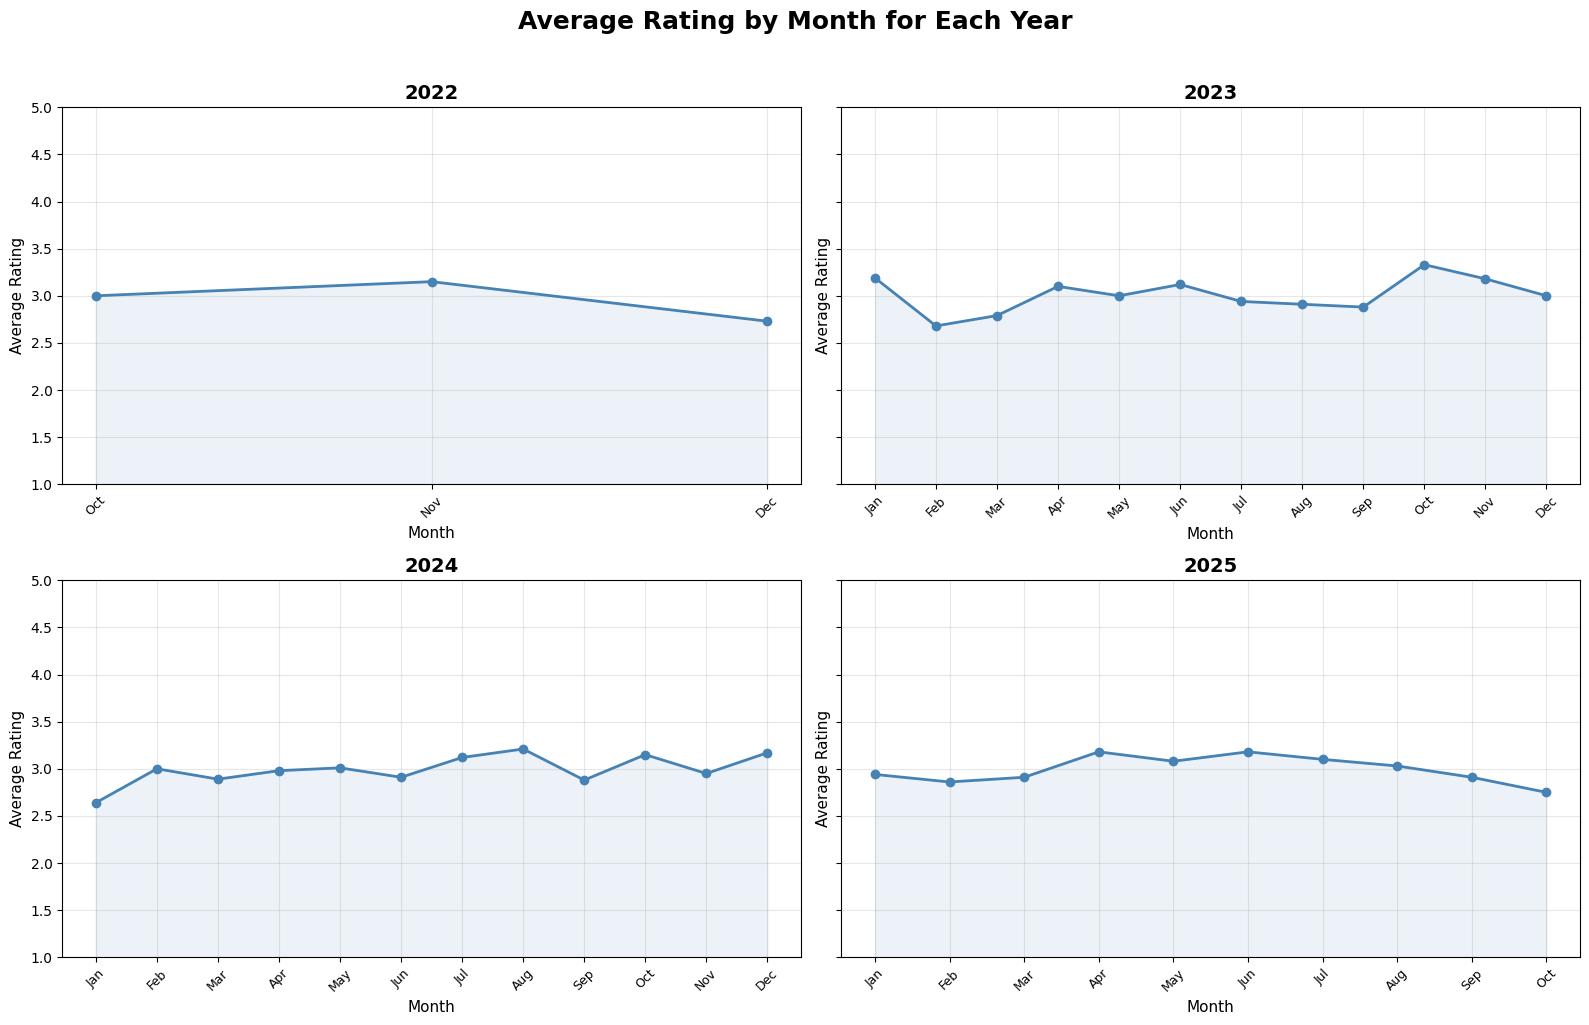

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
years = sorted(df['Year'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Average Rating by Month for Each Year', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten()

for i, (ax, year) in enumerate(zip(axes, years)):
    yearly_data = (df[df['Year'] == year]
                   .groupby('Month')['Rating']
                   .mean()
                   .round(2)
                   .reindex(month_order)
                   .dropna())

    ax.plot(range(len(yearly_data)), yearly_data.values,
            marker='o', color='steelblue', linewidth=2, markersize=6)
    ax.fill_between(range(len(yearly_data)), yearly_data.values,
                    alpha=0.1, color='steelblue')
    ax.set_title(str(year), fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Average Rating', fontsize=11)
    ax.set_xticks(range(len(yearly_data)))
    ax.set_xticklabels([m[:3] for m in yearly_data.index], rotation=45, fontsize=9)
    ax.set_ylim(1, 5)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_visible(True)

plt.tight_layout()

plt.savefig('Rating_by_month_per_year.png', dpi=300, bbox_inches='tight')
plt.savefig('Rating_by_month_per_year.pdf', bbox_inches='tight')
plt.show()

from google.colab import files
files.download('Rating_by_month_per_year.png')
files.download('Rating_by_month_per_year.pdf')

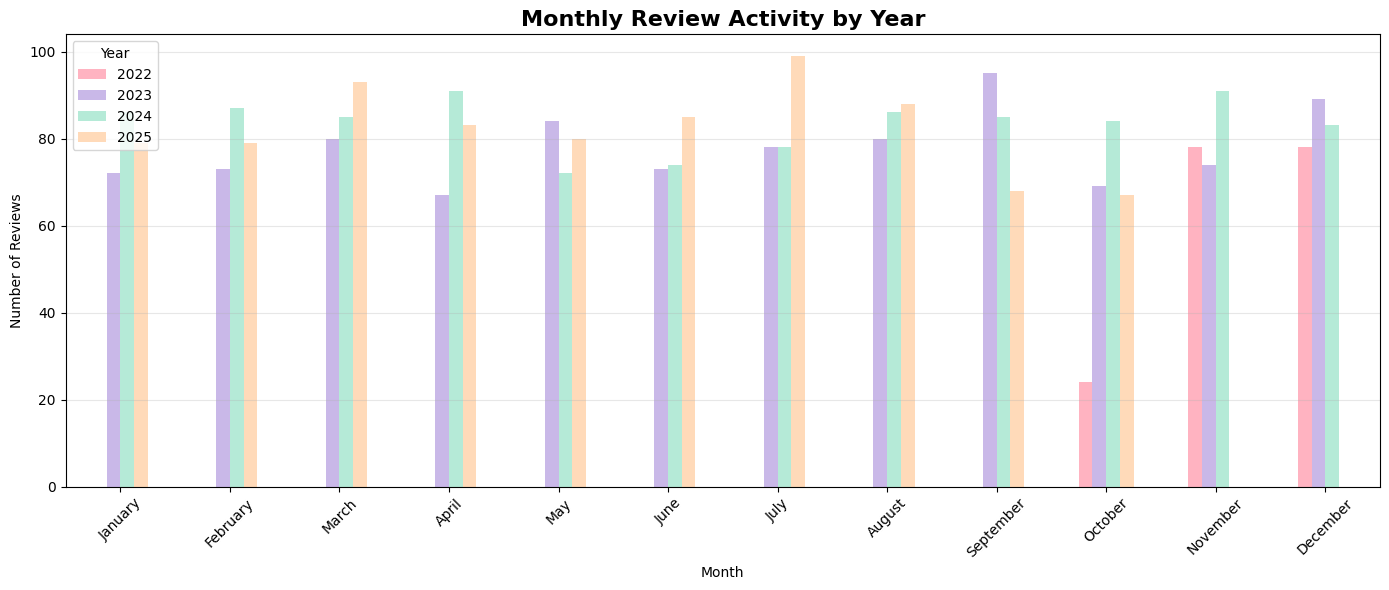

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:

monthly_reviews = (df.groupby(['Month', 'Year']).size().unstack())

monthly_reviews = monthly_reviews.reindex(month_order)

colors = ['#FFB3C1', '#C9B8E8', '#B5EAD7', '#FFDAB9']


monthly_reviews.plot(
    kind='bar',
    figsize=(14, 6),
    color=colors
)

plt.title('Monthly Review Activity by Year', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Year')
plt.tight_layout()


plt.savefig('Monthly_review_activity.png', dpi=300, bbox_inches='tight')
plt.savefig('Monthly_review_activity.pdf', bbox_inches='tight')
plt.show()


from google.colab import files
files.download('Monthly_review_activity.png')
files.download('Monthly_review_activity.pdf')

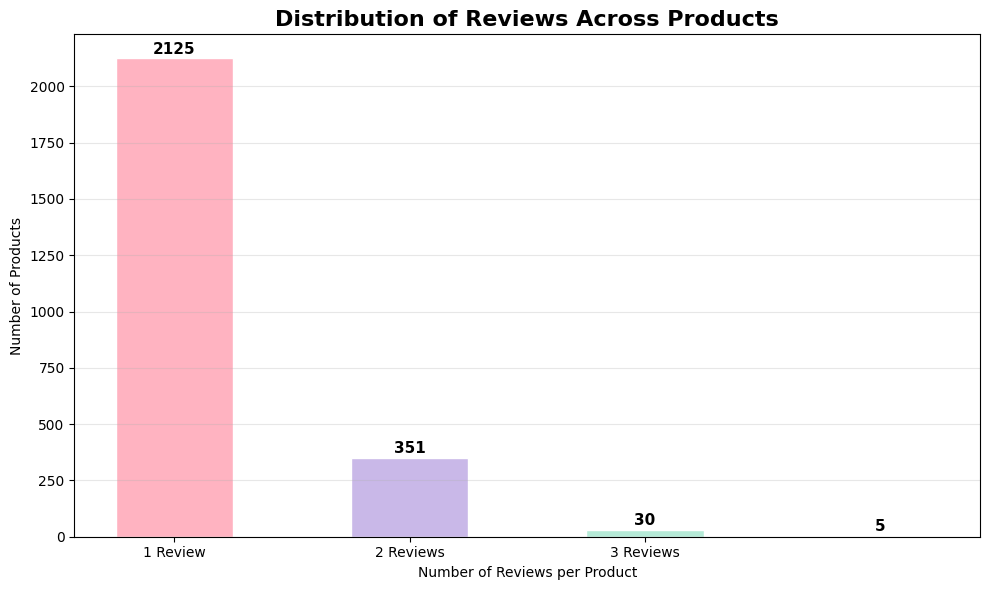

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:

product_review_counts = df['Product_ID'].value_counts()
review_count_dist = product_review_counts.value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    review_count_dist.index,
    review_count_dist.values,
    color=['#FFB3C1', '#C9B8E8', '#B5EAD7'],  # pastel colors per bar
    edgecolor='white',
    width=0.5
)


for i, v in zip(review_count_dist.index, review_count_dist.values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')

plt.title('Distribution of Reviews Across Products', fontsize=16, fontweight='bold')
plt.xlabel('Number of Reviews per Product')
plt.ylabel('Number of Products')
plt.xticks([1, 2, 3], ['1 Review', '2 Reviews', '3 Reviews'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('Reviews_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('Reviews_distribution.pdf', bbox_inches='tight')
plt.show()

from google.colab import files
files.download('Reviews_distribution.png')
files.download('Reviews_distribution.pdf')

# Cleaned csv

In [42]:
df.to_csv('cleaned_dataset_61.csv', index=False)
from google.colab import files
files.download('cleaned_dataset_61.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>